# Catalogue of Gravitational Wave Events

In [1]:
import os
import warnings

import h5py
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy.interpolate

%config InlineBackend.figure_format = 'retina'

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)


def download(url, filename):
    """Download `url` into DATA_DIR (unless already there) and return the local path."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        with open(path, "wb") as f:
            f.write(response.content)
    return path

## Loading the Catalogue

In [2]:
GWOSC_CSV = "https://gwosc.org/eventapi/csv"
catalog_names = ["GWTC-1-confident", "GWTC-2.1-confident", "GWTC-3-confident"]

catalog_files = [download(f"{GWOSC_CSV}/{name}", f"{name}.csv") for name in catalog_names]

gwtc = pd.concat([pd.read_csv(filename) for filename in catalog_files])

n_before = len(gwtc)
gwtc = gwtc[~gwtc["commonName"].duplicated(keep="first")]   # keep the earliest catalog entry
gwtc = gwtc.set_index("commonName").sort_index()

print(f"{n_before} rows in the three catalogs -> {len(gwtc)} distinct events")

100 rows in the three catalogs -> 90 distinct events


In [3]:
key_columns = ["catalog.shortName", "mass_1_source", "mass_2_source", "chirp_mass_source",
               "redshift", "luminosity_distance", "network_matched_filter_snr"]
gwtc[key_columns].head(10)

,catalog.shortName,mass_1_source,mass_2_source,chirp_mass_source,redshift,luminosity_distance,network_matched_filter_snr
commonName,,,,,,,
GW150914,GWTC-1-confident,35.60,30.60,28.600,0.09,440.0,25.2
GW151012,GWTC-1-confident,23.20,13.60,15.200,0.21,1080.0,10.0
GW151226,GWTC-1-confident,13.70,7.70,8.900,0.09,450.0,13.1
GW170104,GWTC-1-confident,30.80,20.00,21.400,0.20,990.0,13.0
GW170608,GWTC-1-confident,11.00,7.60,7.900,0.07,320.0,15.4
GW170729,GWTC-1-confident,50.20,34.00,35.400,0.49,2840.0,10.8
GW170809,GWTC-1-confident,35.00,23.80,24.900,0.20,1030.0,12.4
GW170814,GWTC-1-confident,30.60,25.20,24.100,0.12,600.0,17.2
GW170817,GWTC-1-confident,1.46,1.27,1.186,0.01,40.0,33.0


With this table we can already make some population plots. First the two component masses. By convention $m_1 \geq m_2$, so every event lies below the diagonal.

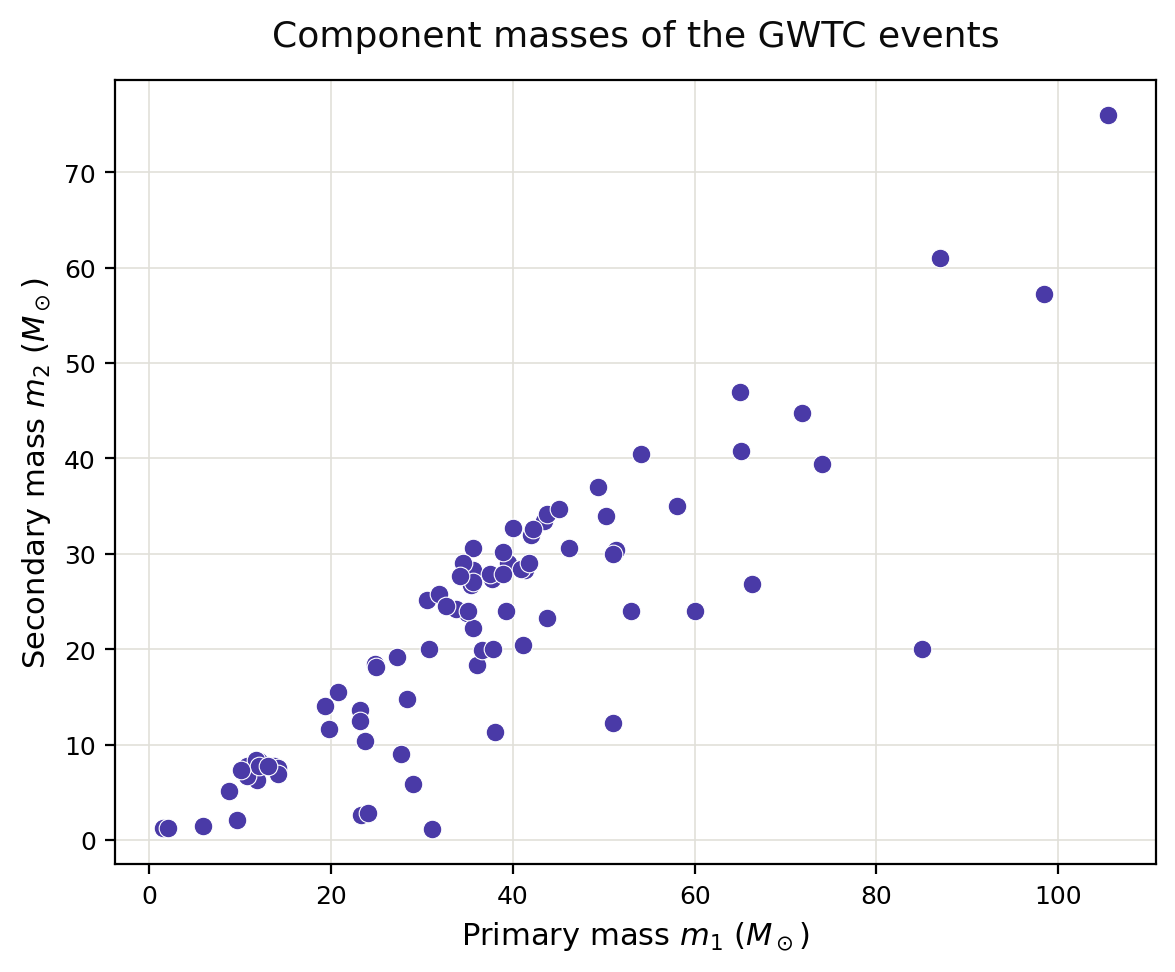

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(gwtc["mass_1_source"], gwtc["mass_2_source"],s=45, color="#4a3aa7", edgecolor="white", linewidth=0.4,)
ax.set_xlabel(r"Primary mass $m_1$ ($M_\odot$)", color="black", fontsize=11)
ax.set_ylabel(r"Secondary mass $m_2$ ($M_\odot$)", color="black", fontsize=11)
ax.set_title("Component masses of the GWTC events", fontsize=13, color="#0b0b0b", pad=12)
ax.grid(True, which="both", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
ax.tick_params(colors="black", labelsize=9)
fig.tight_layout()
plt.show()

Most events are binary black holes with masses of a few tens of solar masses. A handful of systems with $m_2 \lesssim 3\,M_\odot$ stand out along the bottom of the plot: these include the neutron-star binaries at the lower left, and some events with a much heavier primary.

Let's look at the chirp mass against against luminosity distance. Notice: **the events we detect at large distance are the heavy ones**.

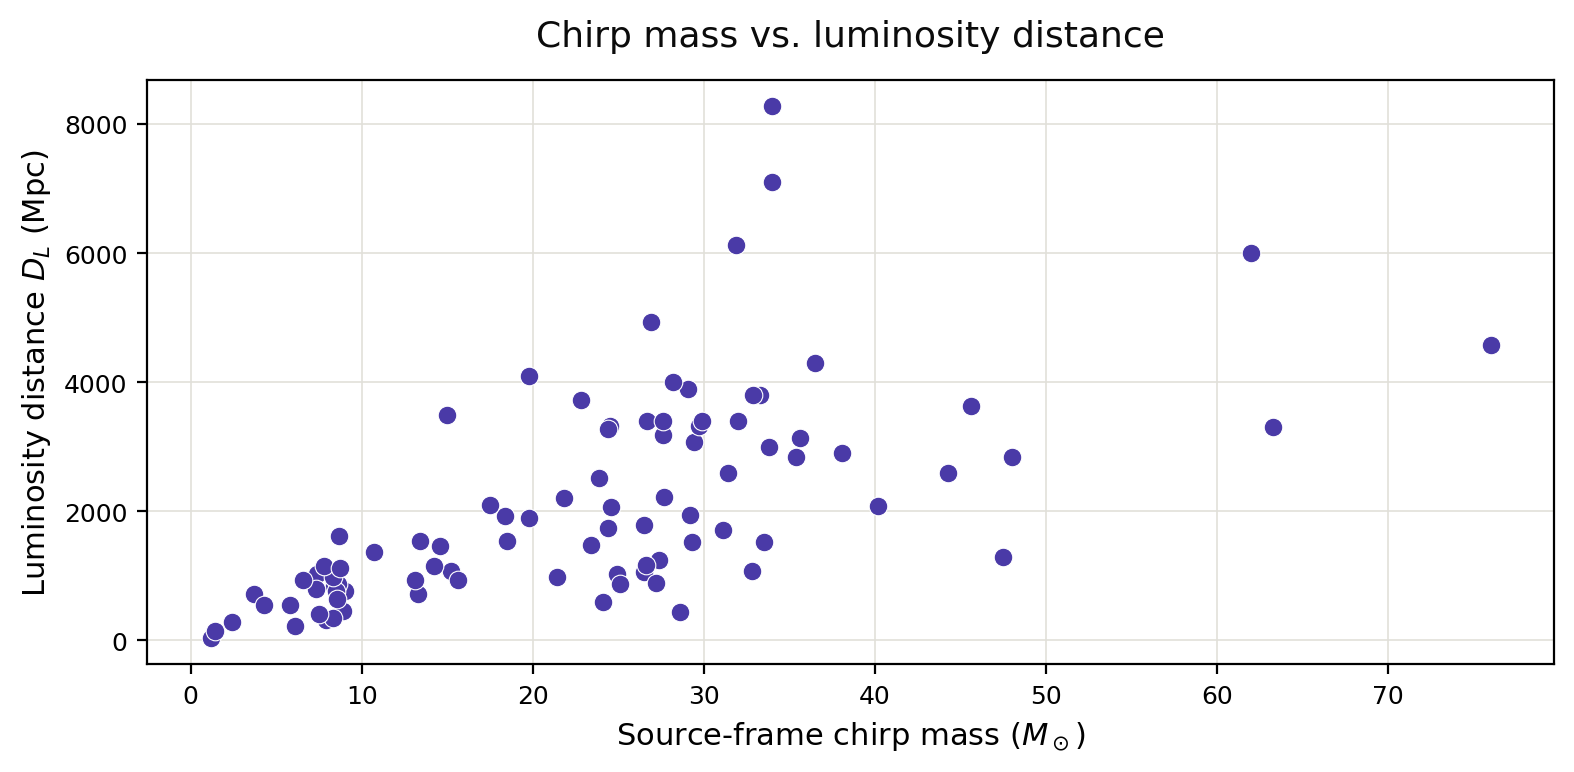

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(gwtc["chirp_mass_source"], gwtc["luminosity_distance"],s=45, color="#4a3aa7",edgecolor="white", linewidth=0.4,)
ax.set_xlabel(r"Source-frame chirp mass ($M_\odot$)", color="black", fontsize=11)
ax.set_ylabel(r"Luminosity distance $D_L$ (Mpc)", color="black", fontsize=11)
ax.set_title("Chirp mass vs. luminosity distance",fontsize=13, color="#0b0b0b", pad=12,)
ax.grid(True, which="both", color="#e1e0d9", linewidth=0.6)#color="#e1e0d9"
ax.set_axisbelow(True)   # gridlines sit behind the points, not on top
ax.tick_params(colors="black", labelsize=9) #"#898781"
fig.tight_layout()
plt.show()

This is a **selection effect**: The heavier binaries are louder and can be seen from further away, while light binaries are only detectable nearby. The amplitude of the gravitational wave strain is given by
$$ h \propto \frac{\mathcal{M}_c^{5/3}}{D_L}$$
where $D_L$ is the luminostiy distance $D_L = D_{phys}\:(1+z)$ and $D_{phys}$ is the physical distance to the GW emission event today. 

## Question: Draw the number of binary mergers as a function of primary mass based on this catalogue? 

Can you see overdensities in the distribution? 

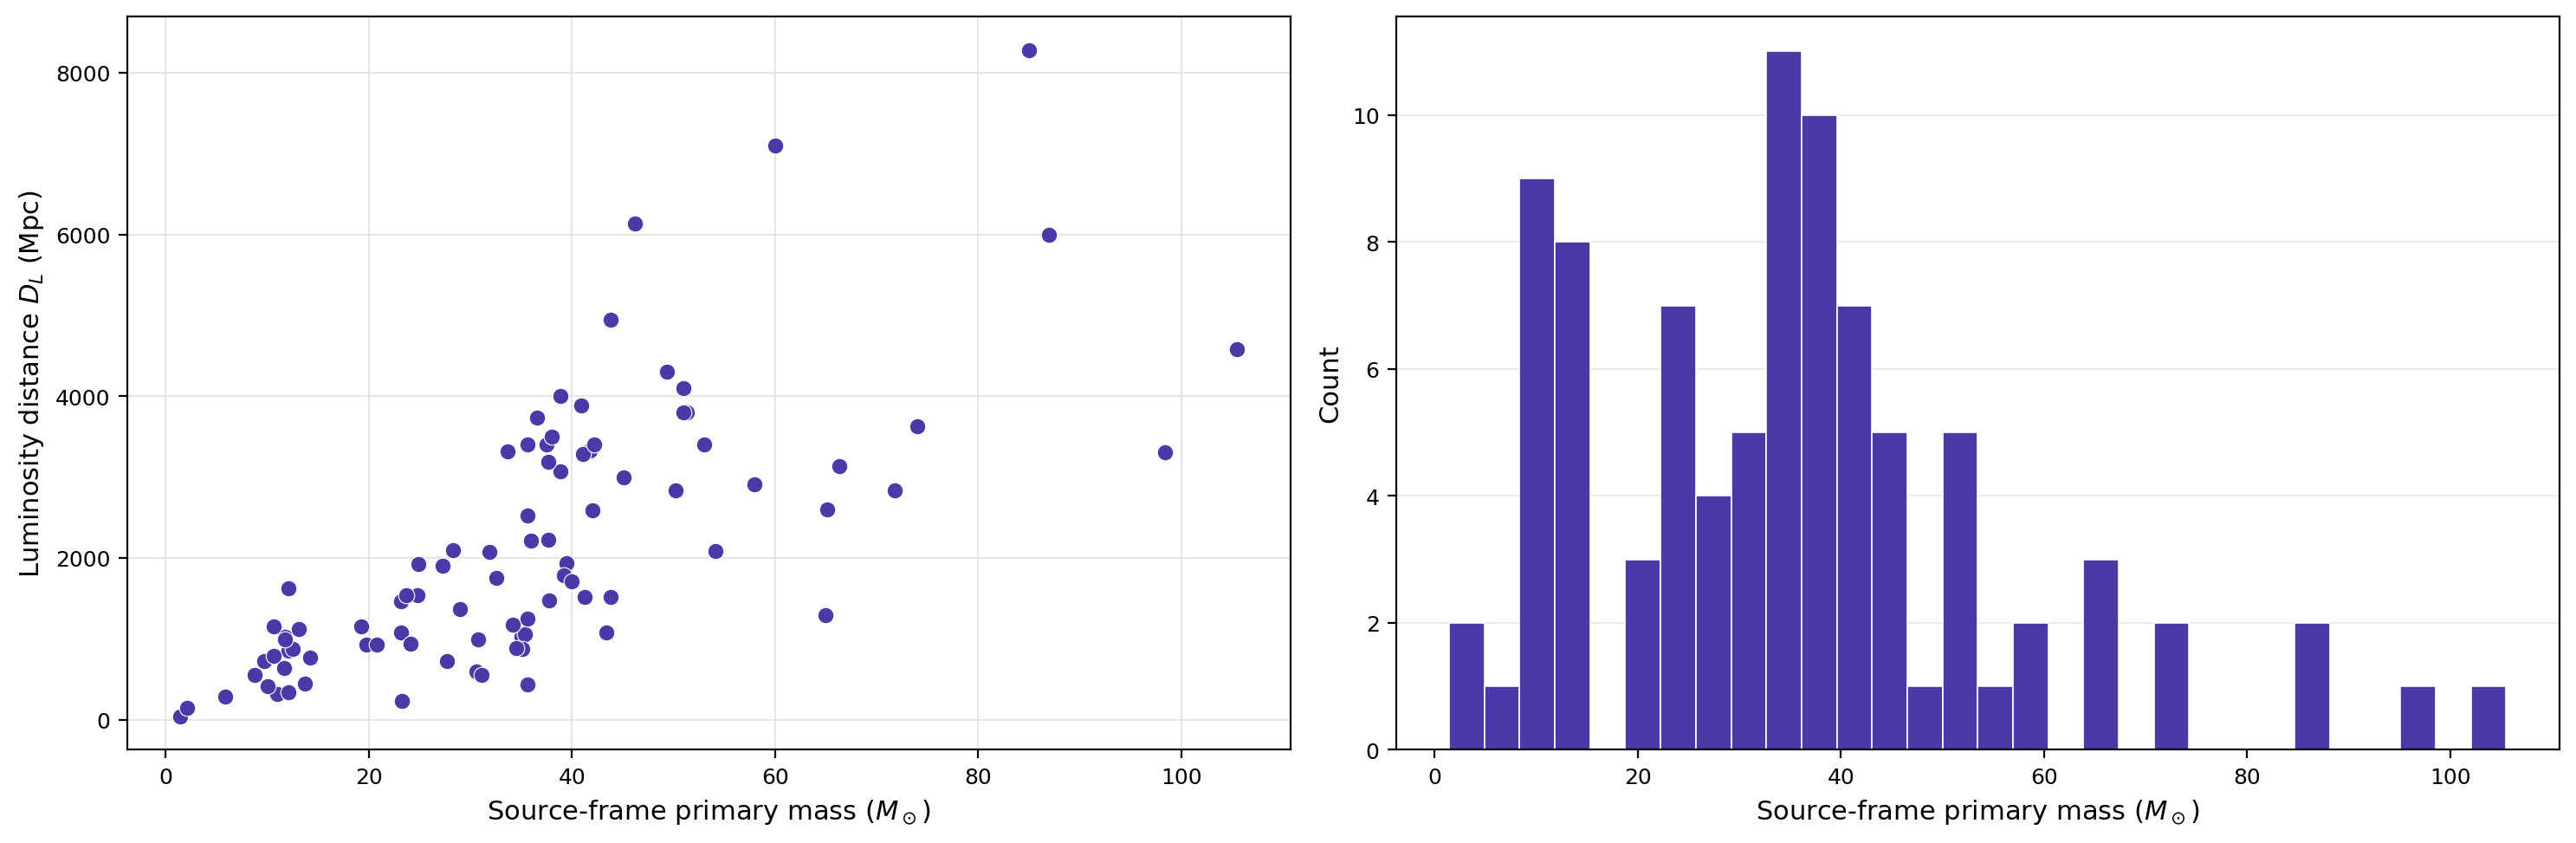

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
#ax1.scatter(gwtc["chirp_mass_source"], gwtc["luminosity_distance"],s=45, color="#4a3aa7", edgecolor="white", linewidth=0.4,)
ax1.scatter(gwtc["mass_1_source"], gwtc["luminosity_distance"],s=45, color="#4a3aa7", edgecolor="white", linewidth=0.4,)
ax1.set_xlabel(r"Source-frame primary mass ($M_\odot$)", color="black", fontsize=11)
ax1.set_ylabel(r"Luminosity distance $D_L$ (Mpc)", color="black", fontsize=11)
#ax1.set_title("Chirp mass vs. luminosity distance", fontsize=13, color="#0b0b0b", pad=12)
ax1.grid(True, which="both", color="#e1e0d9", linewidth=0.6)
ax1.set_axisbelow(True)
ax1.tick_params(colors="black", labelsize=9)

gwtc["mass_1_source"].plot.hist(ax=ax2, bins=30, color="#4a3aa7", edgecolor="white", linewidth=0.6,)
#gwtc["chirp_mass_source"].plot.hist(ax=ax2, bins=30, color="#4a3aa7", edgecolor="white", linewidth=0.6,)

ax2.set_xlabel(r"Source-frame primary mass ($M_\odot$)", color="black", fontsize=11)
ax2.set_ylabel("Count", color="black", fontsize=11)
#ax2.set_title("Distribution of primary masses in the GWTC events",fontsize=13, color="#0b0b0b", loc="left", pad=12,)
ax2.grid(True, axis="y", color="#e1e0d9", linewidth=0.6, alpha=0.8)
ax2.set_axisbelow(True)
ax2.tick_params(colors="black", labelsize=9)
fig.tight_layout()
plt.show()

## Solution

- 10 M$_{\odot}$ peak: Evidence for isolated binary evolution under stable mass transfer
- 35 M$_{\odot}$ peak: The precise astrophysical origin of the ∼35M$_\odot$ feature therefore remains open. O5: Feature is more  consistent with a change in slope in both primary- and secondary mass distributions.

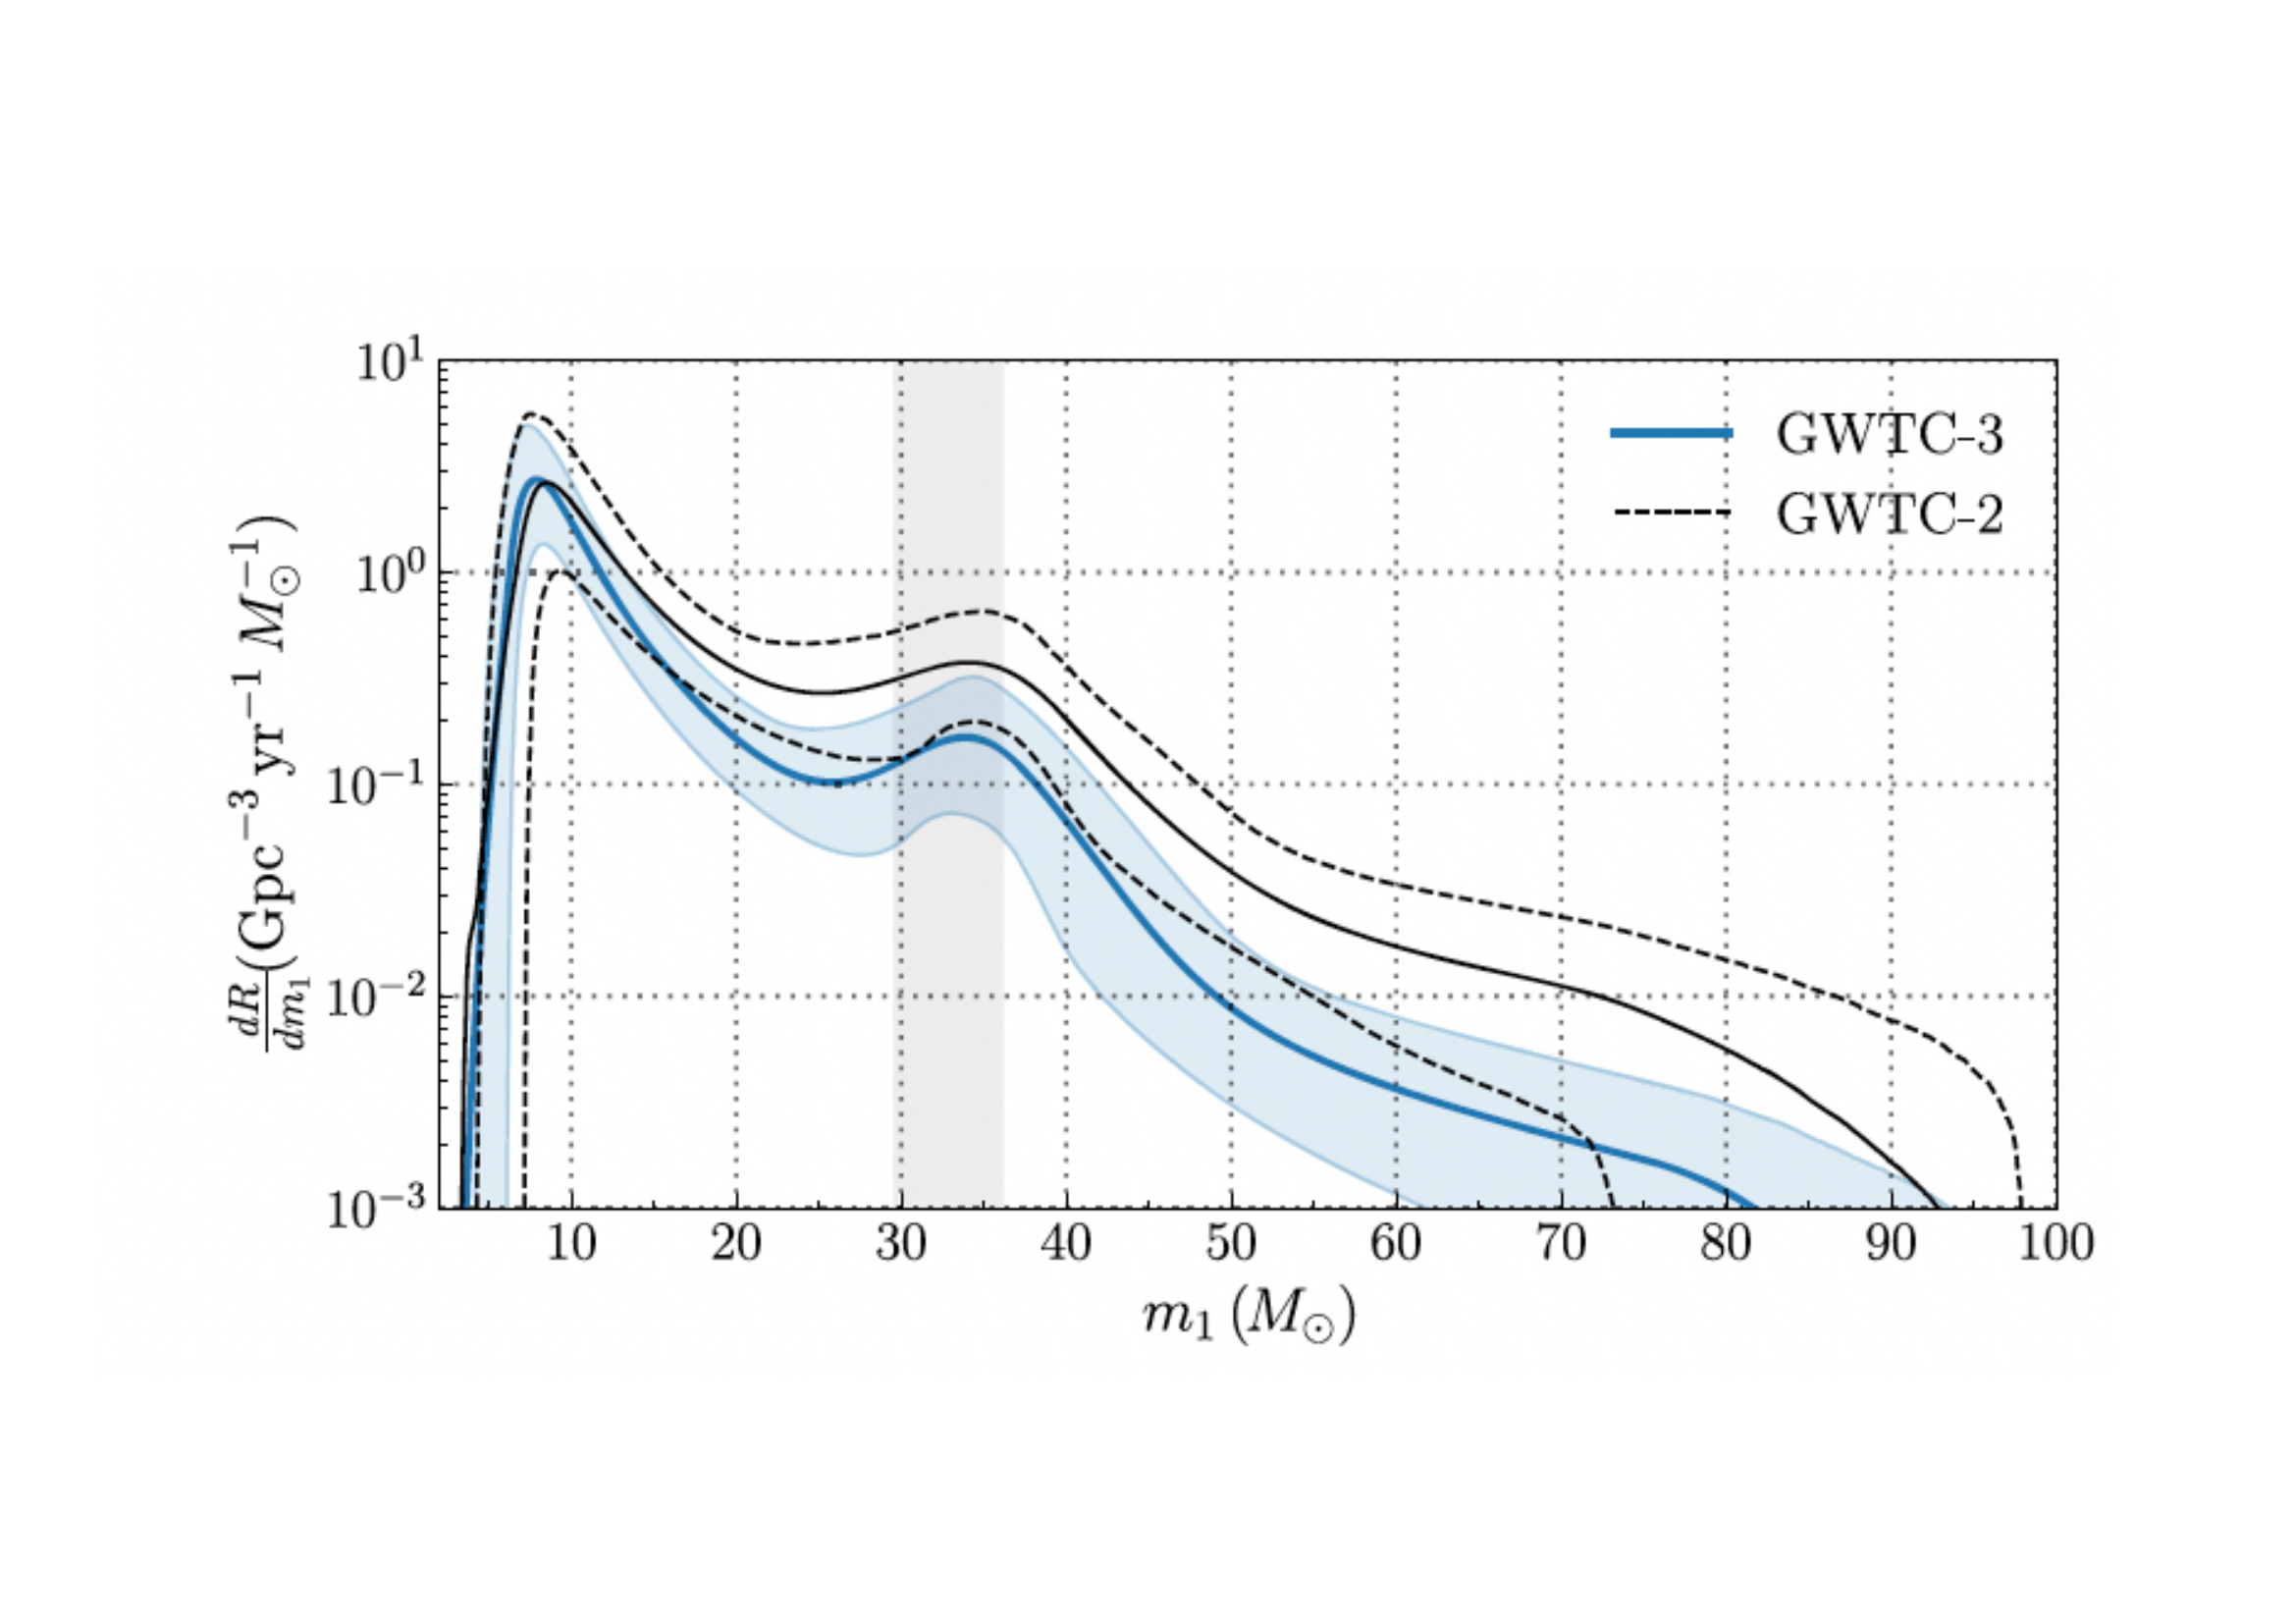

In [18]:
from IPython.display import Image
Image("O3_m1_distribution.png", width=500)  

From most recent observing run we get the following fit

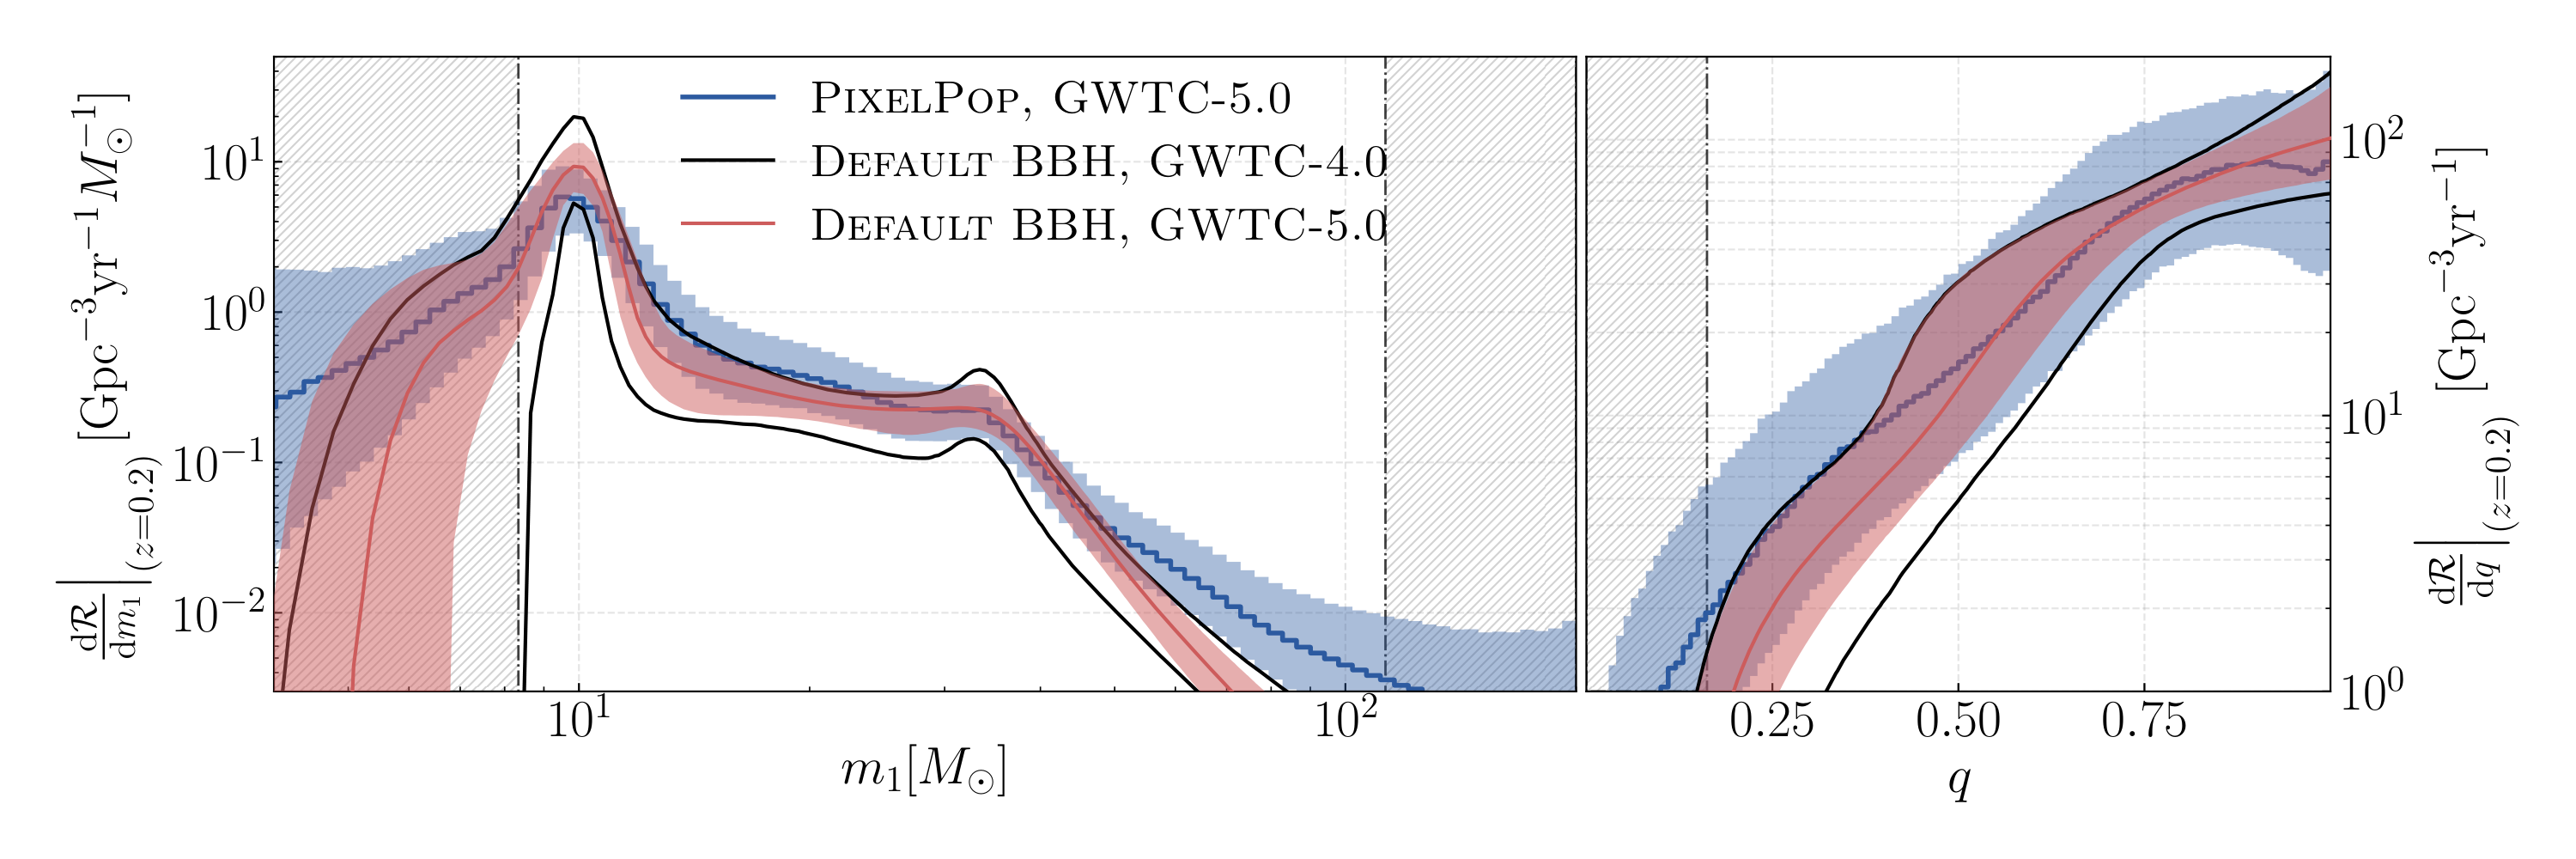

In [19]:
Image("O5_m1_fit.png", width=800) 